# Stage 3: D-MPC实时控制系统 (Flow Matching + CBF + CLF)

## 系统架构

基于D-MPC (Diffusion Model Predictive Control)论文的核心思想:

1. **离线训练阶段**: 
   - 训练Flow Matching模型作为动作提议模型 ρ (action proposal)
   - 训练价值函数 J (用CBF+CLF评分)

2. **在线执行阶段**:
   - 每个时间步进行MPC规划
   - 采样N条候选轨迹
   - 使用CBF+CLF评估每条轨迹
   - 选择最优且安全的轨迹
   - 执行第一步动作

## 关键改进

- **滚动窗口规划**: 不再一次性生成整条轨迹，而是每步重新规划
- **多样性采样**: 利用Flow Matching的随机性生成多条候选
- **安全评分**: 综合考虑安全性(CBF)、目标到达(CLF)、平滑性
- **实时适应**: 可以动态处理环境变化和障碍物移动

生成 8000 条Bezier轨迹...
✓ 生成完成: (8000, 2, 100)


c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ROG\Desktop\lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) m

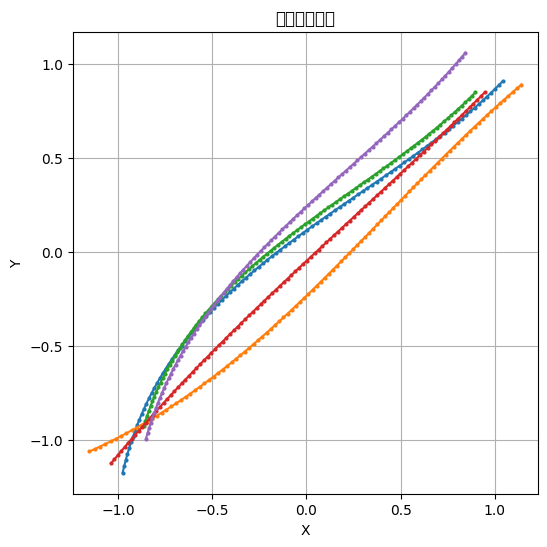

In [1]:
# Cell 0: 生成Bezier轨迹数据（与阶段1相同）

import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchdiffeq
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

def sample_point_in_circle(center, radius):
    angle = np.random.uniform(0, 2 * np.pi)
    r = radius * np.sqrt(np.random.uniform(0, 1))
    return center + r * np.array([np.cos(angle), np.sin(angle)])

def generate_bezier_curve(P0, P1, P2, P3, num_points=100):
    t = np.linspace(0, 1, num_points).reshape(-1, 1)
    B_t = (1 - t)**3 * P0 + 3 * (1 - t)**2 * t * P1 + 3 * (1 - t) * t**2 * P2 + t**3 * P3
    return B_t

baseline_start = np.array([-1, -1])
baseline_end   = np.array([ 1,  1])
radius = 0.2
dominant_endpoint = "start"

if dominant_endpoint == "start":
    perturbation_scale_P1 = 0.7
    perturbation_scale_P2 = 0.01
elif dominant_endpoint == "end":
    perturbation_scale_P1 = 0.1
    perturbation_scale_P2 = 0.3
else:
    perturbation_scale_P1 = perturbation_scale_P2 = 0.2

num_trajectories = 8000
trajectories = []

print(f"生成 {num_trajectories} 条Bezier轨迹...")
for i in range(num_trajectories):
    P0 = sample_point_in_circle(baseline_start, radius)
    P3 = sample_point_in_circle(baseline_end, radius)
    
    base_vector = P3 - P0
    perp_vector = np.array([-base_vector[1], base_vector[0]])
    perp_vector = perp_vector / (np.linalg.norm(perp_vector) + 1e-8)
  
    P1 = P0 + base_vector / 3.0
    P2 = P0 + 2 * base_vector / 3.0
    
    P1 = P1 + np.random.uniform(-perturbation_scale_P1, perturbation_scale_P1) * perp_vector
    P2 = P2 + np.random.uniform(-perturbation_scale_P2, perturbation_scale_P2) * perp_vector
    
    curve = generate_bezier_curve(P0, P1, P2, P3, num_points=100)
    curve = curve.T
    trajectories.append(curve)

trajectories = np.array(trajectories)
print(f"✓ 生成完成: {trajectories.shape}")

num_plots = 5
indices = np.random.choice(len(trajectories), size=num_plots, replace=False)
plt.figure(figsize=(6, 6))
for idx in indices:
    traj = trajectories[idx]
    plt.plot(traj[0], traj[1], marker='o', linestyle='-', markersize=2)
plt.title("训练数据样例")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True)
plt.show()

In [2]:
# Cell 1: 定义模型（保留原有1D UNet）

import torch
import torch.nn as nn
import torch.nn.functional as F

from fmtorch.scheduler import CondOTScheduler
from fmtorch.path import AffinePath
from fmtorch.solver import ODESolver
from fmtorch.utils import ModelWrapper

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

class TrajectoryDataset(Dataset):
    def __init__(self, trajectories):
        self.trajectories = trajectories
        print(f"Dataset shape: {trajectories.shape}")
    def __len__(self):
        return len(self.trajectories)
    def __getitem__(self, idx):
        return torch.tensor(self.trajectories[idx], dtype=torch.float32)

class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        if t.dim() == 0:
            t = t.unsqueeze(0)
        if t.dim() == 1:
            t = t.unsqueeze(-1)
        emb = t * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

class ResBlock1D(nn.Module):
    def __init__(self, channels, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Sequential(Mish(), nn.Linear(time_emb_dim, channels))
        self.block = nn.Sequential(
            nn.GroupNorm(8, channels), Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
            nn.GroupNorm(8, channels), Mish(),
            nn.Conv1d(channels, channels, 3, padding=1),
        )
    def forward(self, x, t_emb):
        h = self.block(x)
        if t_emb.shape[0] == 1 and x.shape[0] > 1:
            t_emb = t_emb.expand(x.shape[0], -1)
        h = h + self.time_mlp(t_emb)[:, :, None]
        return x + h

class SimpleUNet1D(nn.Module):
    def __init__(self, time_emb_dim=128, hidden_dim=128):
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.hidden_dim = hidden_dim
        
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4), Mish(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )
        
        self.conv_in = nn.Conv1d(2, hidden_dim, 3, padding=1)
        
        self.down1_block = nn.ModuleList([ResBlock1D(hidden_dim, time_emb_dim), ResBlock1D(hidden_dim, time_emb_dim)])
        self.down1_sample = nn.Conv1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        
        self.down2_block = nn.ModuleList([ResBlock1D(hidden_dim, time_emb_dim), ResBlock1D(hidden_dim, time_emb_dim)])
        self.down2_sample = nn.Conv1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        
        self.mid_block = nn.ModuleList([ResBlock1D(hidden_dim, time_emb_dim), ResBlock1D(hidden_dim, time_emb_dim)])
        
        self.up2_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up2_block = nn.ModuleList([ResBlock1D(hidden_dim * 2, time_emb_dim), ResBlock1D(hidden_dim * 2, time_emb_dim)])
        self.up2_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        self.up1_sample = nn.ConvTranspose1d(hidden_dim, hidden_dim, 4, stride=2, padding=1)
        self.up1_block = nn.ModuleList([ResBlock1D(hidden_dim * 2, time_emb_dim), ResBlock1D(hidden_dim * 2, time_emb_dim)])
        self.up1_conv = nn.Conv1d(hidden_dim * 2, hidden_dim, 1)
        
        self.conv_out = nn.Conv1d(hidden_dim, 2, 3, padding=1)
        
    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        
        h = self.conv_in(x)
        
        # Down 1
        for block in self.down1_block:
            h = block(h, t_emb)
        skip1 = h
        h = self.down1_sample(h)
        
        # Down 2
        for block in self.down2_block:
            h = block(h, t_emb)
        skip2 = h
        h = self.down2_sample(h)
        
        # Middle
        for block in self.mid_block:
            h = block(h, t_emb)
        
        # Up 2
        h = self.up2_sample(h)
        h = torch.cat([h, skip2], dim=1)
        for block in self.up2_block:
            h = block(h, t_emb)
        h = self.up2_conv(h)
        
        # Up 1
        h = self.up1_sample(h)
        h = torch.cat([h, skip1], dim=1)
        for block in self.up1_block:
            h = block(h, t_emb)
        h = self.up1_conv(h)
        
        out = self.conv_out(h)
        return out

print("✓ 模型定义完成")

使用设备: cuda
✓ 模型定义完成


In [4]:
# Cell 2: 训练Flow Matching模型

from tqdm import tqdm

# 检查是否存在已训练的模型
model_path = "fm_model_1dunet.pth"
train_from_scratch = not os.path.exists(model_path)

if train_from_scratch:
    print("未找到预训练模型，开始训练...")
    print("="*60)
    
    # 创建数据集和数据加载器
    dataset = TrajectoryDataset(trajectories)
    train_loader = DataLoader(dataset, batch_size=128, shuffle=True)
    
    # 初始化模型
    model = SimpleUNet1D(time_emb_dim=128, hidden_dim=128).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler_lr = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
    
    # Flow Matching调度器
    fm_scheduler = CondOTScheduler()
    path = AffinePath()
    
    # 训练循环
    epochs = 50
    model.train()
    
    for epoch in range(epochs):
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for batch_idx, z1 in enumerate(pbar):
            z1 = z1.to(device)
            B = z1.shape[0]
            
            # 采样时间和噪声
            t = torch.rand(B, device=device).clamp(0.005, 0.995)
            z0 = torch.randn_like(z1)
            
            # Flow Matching目标
            zt, target = fm_scheduler.add_noise(z1, z0, t.unsqueeze(-1).unsqueeze(-1))
            
            # 预测速度场
            v_pred = model(zt, t)
            
            # 计算损失
            loss = F.mse_loss(v_pred, target)
            
            # 反向传播
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            total_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        scheduler_lr.step()
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}: Avg Loss = {avg_loss:.4f}")
    
    # 保存模型
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': epochs
    }, model_path)
    print(f"\n✓ 模型已保存到 {model_path}")
    
else:
    print(f"✓ 找到预训练模型: {model_path}")
    print("加载模型...")
    
    model = SimpleUNet1D(time_emb_dim=128, hidden_dim=128).to(device)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✓ 模型加载完成 (训练epoch: {checkpoint.get('epoch', 'unknown')})")

model.eval()
print("\n✓ Flow Matching模型准备就绪")

未找到预训练模型，开始训练...
Dataset shape: (8000, 2, 100)


TypeError: AffinePath.__init__() missing 1 required positional argument: 'scheduler'

## D-MPC核心组件

### 1. 动作提议模型 (Action Proposal ρ)
使用训练好的Flow Matching模型生成多样化的轨迹候选

### 2. 价值函数 (Value Function J)
综合评估轨迹的质量:
- **安全性**: CBF约束满足程度
- **目标性**: CLF到达目标的能力
- **平滑性**: 轨迹的连续性和平滑度
- **效率性**: 轨迹长度和能量消耗

### 3. 规划器 (Planner)
采样-评估-选择的MPC框架

In [ ]:
# Cell 3: 定义障碍物环境

obstacles = [
    {'center': np.array([0.0, 0.0]), 'radius': 0.3},
    {'center': np.array([0.5, 0.5]), 'radius': 0.2},
    {'center': np.array([-0.3, 0.6]), 'radius': 0.15}
]

print("✓ 障碍物环境:")
for i, obs in enumerate(obstacles):
    print(f"  障碍物{i+1}: 中心={obs['center']}, 半径={obs['radius']}")

# 可视化障碍物
fig, ax = plt.subplots(figsize=(8, 8))
for obs in obstacles:
    circle = plt.Circle(obs['center'], obs['radius'], color='red', alpha=0.3)
    ax.add_patch(circle)
    circle_safe = plt.Circle(obs['center'], obs['radius'] + 0.2, 
                             color='orange', fill=False, linestyle='--', alpha=0.6)
    ax.add_patch(circle_safe)

ax.scatter([-1], [-1], c='green', s=200, marker='o', label='起点', zorder=5)
ax.scatter([1], [1], c='red', s=200, marker='*', label='终点', zorder=5)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title('障碍物环境', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
# Cell 4: CBF和CLF函数定义

def barrier_function(pos, obstacle):
    """
    障碍函数 h(x) = ||x - c||^2 - R^2
    h > 0: 安全
    h = 0: 边界
    h < 0: 碰撞
    """
    return np.sum((pos - obstacle['center'])**2) - obstacle['radius']**2

def barrier_gradient(pos, obstacle):
    """障碍函数梯度 ∇h = 2(x - c)"""
    return 2 * (pos - obstacle['center'])

def lyapunov_function(pos, goal):
    """
    Lyapunov函数 V(x) = 0.5 * ||x - goal||^2
    """
    return 0.5 * np.sum((pos - goal)**2)

def lyapunov_gradient(pos, goal):
    """Lyapunov函数梯度 ∇V = (x - goal)"""
    return pos - goal

def evaluate_cbf_safety(trajectory, obstacles, alpha=1.0, safety_margin=0.2):
    """
    评估轨迹的CBF安全性
    返回: 安全分数 (越高越好)
    """
    T = trajectory.shape[1]
    safety_score = 0.0
    violations = 0
    
    for t in range(T):
        pos = trajectory[:, t]
        min_barrier = float('inf')
        
        for obs in obstacles:
            h = barrier_function(pos, obs)
            # 考虑安全边界
            h_safe = h - (2 * obs['radius'] * safety_margin + safety_margin**2)
            min_barrier = min(min_barrier, h_safe)
            
            if h < 0:  # 碰撞
                violations += 1
        
        # 将barrier值转换为分数
        if min_barrier > 0:
            safety_score += np.sqrt(min_barrier)  # 安全时给予正分
        else:
            safety_score += 10 * min_barrier  # 违反时大幅扣分
    
    return safety_score / T, violations

def evaluate_clf_convergence(trajectory, goal, c=1.0):
    """
    评估轨迹的CLF收敛性
    返回: 收敛分数 (越高越好)
    """
    T = trajectory.shape[1]
    convergence_score = 0.0
    
    for t in range(T - 1):
        pos = trajectory[:, t]
        pos_next = trajectory[:, t + 1]
        
        V_t = lyapunov_function(pos, goal)
        V_next = lyapunov_function(pos_next, goal)
        
        # CLF条件: V̇ ≤ -c*V
        # 离散近似: (V_{t+1} - V_t) / dt ≤ -c*V_t
        V_dot = V_next - V_t
        desired_decrease = -c * V_t * 0.01  # dt = 0.01
        
        if V_dot <= desired_decrease:
            convergence_score += 1.0
        else:
            # 扣分: 未能按照CLF要求收敛
            convergence_score -= (V_dot - desired_decrease)
    
    # 终点奖励
    final_distance = np.linalg.norm(trajectory[:, -1] - goal)
    convergence_score += max(0, 1.0 - final_distance)  # 越接近终点越好
    
    return convergence_score / T

def evaluate_smoothness(trajectory):
    """
    评估轨迹平滑性 (曲率和加速度)
    返回: 平滑分数 (越高越好)
    """
    T = trajectory.shape[1]
    
    # 计算速度
    velocities = np.diff(trajectory, axis=1)
    
    # 计算加速度
    accelerations = np.diff(velocities, axis=1)
    
    # 速度变化率 (平滑性)
    velocity_smoothness = -np.mean(np.linalg.norm(accelerations, axis=0))
    
    # 速度大小的一致性
    velocity_magnitudes = np.linalg.norm(velocities, axis=0)
    velocity_consistency = -np.std(velocity_magnitudes)
    
    smoothness_score = velocity_smoothness + velocity_consistency
    return smoothness_score

def evaluate_trajectory(trajectory, obstacles, goal, weights=None):
    """
    综合价值函数 J
    
    J = w_safety * safety_score 
        + w_convergence * convergence_score 
        + w_smooth * smoothness_score
        - w_penalty * violations
    """
    if weights is None:
        weights = {
            'safety': 10.0,        # CBF安全性权重
            'convergence': 5.0,    # CLF收敛性权重
            'smoothness': 2.0,     # 平滑性权重
            'violation_penalty': 100.0  # 碰撞惩罚
        }
    
    # 评估各项指标
    safety_score, violations = evaluate_cbf_safety(trajectory, obstacles)
    convergence_score = evaluate_clf_convergence(trajectory, goal)
    smoothness_score = evaluate_smoothness(trajectory)
    
    # 综合得分
    total_score = (
        weights['safety'] * safety_score +
        weights['convergence'] * convergence_score +
        weights['smoothness'] * smoothness_score -
        weights['violation_penalty'] * violations
    )
    
    diagnostics = {
        'total': total_score,
        'safety': safety_score,
        'convergence': convergence_score,
        'smoothness': smoothness_score,
        'violations': violations
    }
    
    return total_score, diagnostics

print("✓ CBF/CLF评估函数定义完成")
print("  - barrier_function: CBF障碍函数")
print("  - lyapunov_function: CLF李雅普诺夫函数")
print("  - evaluate_cbf_safety: CBF安全性评分")
print("  - evaluate_clf_convergence: CLF收敛性评分")
print("  - evaluate_smoothness: 轨迹平滑性评分")
print("  - evaluate_trajectory: 综合价值函数J")

In [ ]:
# Cell 5: D-MPC核心 - 采样式规划器

def sample_trajectory_candidates(model, start_pos, goal_pos, N=10, horizon=30, 
                                temperature=1.0, device='cpu'):
    """
    使用Flow Matching模型采样N条候选轨迹
    
    参数:
        model: 训练好的Flow Matching模型
        start_pos: 起点 (2,)
        goal_pos: 终点 (2,)
        N: 采样数量
        horizon: 预测时域长度
        temperature: 采样温度 (控制多样性)
    
    返回:
        candidates: List of (2, horizon) numpy arrays
    """
    model.eval()
    candidates = []
    
    with torch.no_grad():
        for _ in range(N):
            # 初始化噪声轨迹
            z0 = torch.randn(1, 2, horizon, device=device) * temperature
            
            # 设置起点和终点条件
            z0[0, :, 0] = torch.tensor(start_pos, device=device)
            z0[0, :, -1] = torch.tensor(goal_pos, device=device)
            
            # ODE求解 - Flow Matching采样
            def ode_func(t, zt):
                t_tensor = torch.tensor([t], device=device)
                return model(zt, t_tensor)
            
            # 使用欧拉方法或RK4积分
            t_span = torch.linspace(0, 1, 20, device=device)
            zt = z0
            
            for i in range(len(t_span) - 1):
                t = t_span[i]
                dt = t_span[i+1] - t_span[i]
                v = model(zt, t.unsqueeze(0))
                zt = zt + v * dt
            
            # 转换为numpy
            trajectory = zt[0].cpu().numpy()  # (2, horizon)
            candidates.append(trajectory)
    
    return candidates

def dmpc_planner(model, current_pos, goal_pos, obstacles, N=20, horizon=30, 
                value_weights=None, device='cpu'):
    """
    D-MPC规划器 (Algorithm 2的实现)
    
    参数:
        model: Flow Matching模型 (动作提议 ρ)
        current_pos: 当前位置 (2,)
        goal_pos: 目标位置 (2,)
        obstacles: 障碍物列表
        N: 候选轨迹数量
        horizon: 预测时域
        value_weights: 价值函数权重
    
    返回:
        best_action: 最优动作 (2,)
        best_trajectory: 最优轨迹 (2, horizon)
        all_candidates: 所有候选轨迹
        all_scores: 所有候选分数
    """
    # 1. 采样N条候选轨迹 (动作提议模型 ρ)
    candidates = sample_trajectory_candidates(
        model, current_pos, goal_pos, N=N, horizon=horizon, 
        temperature=1.0, device=device
    )
    
    # 2. 评估每条候选轨迹 (价值函数 J)
    best_score = -float('inf')
    best_idx = 0
    all_scores = []
    all_diagnostics = []
    
    for i, traj in enumerate(candidates):
        score, diag = evaluate_trajectory(traj, obstacles, goal_pos, value_weights)
        all_scores.append(score)
        all_diagnostics.append(diag)
        
        if score > best_score:
            best_score = score
            best_idx = i
    
    # 3. 选择最优轨迹
    best_trajectory = candidates[best_idx]
    
    # 4. 返回第一步动作 (MPC receding horizon)
    best_action = best_trajectory[:, 1] - best_trajectory[:, 0]
    
    return {
        'action': best_action,
        'trajectory': best_trajectory,
        'score': best_score,
        'diagnostics': all_diagnostics[best_idx],
        'all_candidates': candidates,
        'all_scores': all_scores,
        'all_diagnostics': all_diagnostics
    }

print("✓ D-MPC规划器定义完成")
print("  核心流程:")
print("    1. 使用Flow Matching采样N条候选轨迹 (动作提议)")
print("    2. 使用CBF+CLF评估每条轨迹 (价值函数)")
print("    3. 选择最优轨迹并执行第一步 (MPC)")

In [ ]:
# Cell 6: D-MPC主循环 - 实时滚动规划

def dmpc_rollout(model, start_pos, goal_pos, obstacles, 
                max_steps=100, N_candidates=20, horizon=30,
                dt=0.01, device='cpu'):
    """
    D-MPC完整执行循环 (Algorithm 1的实现)
    
    每个时间步:
        1. 调用规划器获取最优动作
        2. 执行动作
        3. 更新状态
        4. 重复直到到达目标或达到最大步数
    """
    trajectory = [start_pos.copy()]
    current_pos = start_pos.copy()
    
    all_planning_info = []
    
    for step in range(max_steps):
        # 检查是否到达目标
        dist_to_goal = np.linalg.norm(current_pos - goal_pos)
        if dist_to_goal < 0.05:
            print(f"✓ 到达目标! (步数: {step})")
            break
        
        # MPC规划
        planning_result = dmpc_planner(
            model, current_pos, goal_pos, obstacles,
            N=N_candidates, horizon=horizon, device=device
        )
        
        # 执行动作
        action = planning_result['action']
        current_pos = current_pos + action * dt
        
        # 记录轨迹
        trajectory.append(current_pos.copy())
        all_planning_info.append(planning_result)
        
        # 打印进度
        if step % 10 == 0:
            print(f"步 {step}: 距离目标 {dist_to_goal:.3f}, "
                  f"得分 {planning_result['score']:.2f}, "
                  f"碰撞 {planning_result['diagnostics']['violations']}")
    
    trajectory = np.array(trajectory).T  # (2, T)
    
    return {
        'trajectory': trajectory,
        'planning_info': all_planning_info,
        'success': dist_to_goal < 0.05,
        'steps': len(trajectory)
    }

print("✓ D-MPC主循环定义完成")

In [ ]:
# Cell 7: 执行D-MPC规划

print("="*70)
print("开始D-MPC实时规划")
print("="*70)

start_pos = np.array([-1.0, -1.0])
goal_pos = np.array([1.0, 1.0])

print(f"起点: {start_pos}")
print(f"终点: {goal_pos}")
print(f"障碍物数量: {len(obstacles)}")
print()

# 执行D-MPC
result = dmpc_rollout(
    model=model,
    start_pos=start_pos,
    goal_pos=goal_pos,
    obstacles=obstacles,
    max_steps=100,
    N_candidates=15,  # 每步采样15条候选
    horizon=25,       # 预测25步
    dt=0.02,
    device=device
)

dmpc_trajectory = result['trajectory']

print("\n" + "="*70)
print("D-MPC执行完成")
print("="*70)
print(f"成功: {result['success']}")
print(f"总步数: {result['steps']}")
print(f"最终距离: {np.linalg.norm(dmpc_trajectory[:, -1] - goal_pos):.4f}")

# 安全性验证
collisions = 0
for t in range(dmpc_trajectory.shape[1]):
    pos = dmpc_trajectory[:, t]
    for obs in obstacles:
        if np.linalg.norm(pos - obs['center']) < obs['radius']:
            collisions += 1
            break

print(f"碰撞点数: {collisions}")
print()

if collisions == 0 and result['success']:
    print("🎉 完美! 成功到达目标且无碰撞!")
elif collisions == 0:
    print("✓ 良好! 无碰撞但未完全到达目标")
else:
    print("⚠️ 警告: 存在碰撞")

In [ ]:
# Cell 8: 可视化D-MPC执行过程

fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# 图1: 最终轨迹
ax1 = axes[0, 0]
for obs in obstacles:
    circle = plt.Circle(obs['center'], obs['radius'], color='red', alpha=0.3)
    ax1.add_patch(circle)
    circle_safe = plt.Circle(obs['center'], obs['radius'] + 0.2, 
                            color='orange', fill=False, linestyle='--', alpha=0.6)
    ax1.add_patch(circle_safe)

ax1.plot(dmpc_trajectory[0], dmpc_trajectory[1], 
        'b-', linewidth=3, alpha=0.8, label='D-MPC轨迹')
ax1.scatter(start_pos[0], start_pos[1], c='green', s=200, marker='o', 
           edgecolors='black', linewidths=2, zorder=5, label='起点')
ax1.scatter(goal_pos[0], goal_pos[1], c='red', s=200, marker='*', 
           edgecolors='black', linewidths=2, zorder=5, label='终点')
ax1.set_title('D-MPC最终轨迹', fontsize=14, fontweight='bold')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.axis('equal')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 图2: 规划过程中的候选轨迹 (显示某一步)
ax2 = axes[0, 1]
if len(result['planning_info']) > 0:
    # 选择中间某一步的规划信息
    step_to_show = min(10, len(result['planning_info']) - 1)
    planning_step = result['planning_info'][step_to_show]
    
    for obs in obstacles:
        circle = plt.Circle(obs['center'], obs['radius'], color='red', alpha=0.3)
        ax2.add_patch(circle)
    
    # 显示所有候选轨迹
    for i, cand in enumerate(planning_step['all_candidates']):
        score = planning_step['all_scores'][i]
        alpha = 0.2 if i != 0 else 0.8  # 最优的更亮
        color = 'green' if score == planning_step['score'] else 'gray'
        ax2.plot(cand[0], cand[1], color=color, alpha=alpha, linewidth=1)
    
    # 标记当前位置
    current = dmpc_trajectory[:, step_to_show]
    ax2.scatter(current[0], current[1], c='blue', s=150, marker='o', zorder=5)
    
    ax2.set_title(f'步骤 {step_to_show} 的候选轨迹\n(绿色=最优, 灰色=其他)', 
                 fontsize=14, fontweight='bold')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.axis('equal')
    ax2.grid(True, alpha=0.3)

# 图3: 安全距离随时间变化
ax3 = axes[1, 0]
T = dmpc_trajectory.shape[1]
min_distances = np.zeros(T)

for t in range(T):
    pos = dmpc_trajectory[:, t]
    dists = [np.linalg.norm(pos - obs['center']) - obs['radius'] for obs in obstacles]
    min_distances[t] = min(dists)

ax3.plot(min_distances, 'b-', linewidth=2)
ax3.axhline(y=0, color='red', linestyle='-', linewidth=2, label='碰撞线')
ax3.axhline(y=0.2, color='orange', linestyle='--', linewidth=2, label='安全边界')
ax3.set_title('安全距离监控', fontsize=14, fontweight='bold')
ax3.set_xlabel('时间步')
ax3.set_ylabel('到最近障碍物的距离')
ax3.grid(True, alpha=0.3)
ax3.legend()

# 图4: 价值函数分数变化
ax4 = axes[1, 1]
scores = [info['score'] for info in result['planning_info']]
safety_scores = [info['diagnostics']['safety'] for info in result['planning_info']]
convergence_scores = [info['diagnostics']['convergence'] for info in result['planning_info']]

ax4.plot(scores, 'b-', linewidth=2, label='总分数', alpha=0.7)
ax4.plot(safety_scores, 'r--', linewidth=2, label='CBF安全分', alpha=0.7)
ax4.plot(convergence_scores, 'g--', linewidth=2, label='CLF收敛分', alpha=0.7)
ax4.set_title('价值函数得分变化', fontsize=14, fontweight='bold')
ax4.set_xlabel('规划步骤')
ax4.set_ylabel('分数')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

print("✓ D-MPC执行过程可视化完成")

In [ ]:
# Cell 9: 对比实验 - D-MPC vs 基础FM vs CBF

print("="*70)
print("对比实验: D-MPC vs 基础生成 vs 传统CBF")
print("="*70)

# 1. 基础Flow Matching生成 (一次性生成整条轨迹)
print("\n1. 基础Flow Matching生成...")
baseline_candidates = sample_trajectory_candidates(
    model, start_pos, goal_pos, N=5, horizon=100, temperature=1.0, device=device
)
baseline_traj = baseline_candidates[0]  # 取第一条

baseline_collisions = 0
for t in range(baseline_traj.shape[1]):
    pos = baseline_traj[:, t]
    for obs in obstacles:
        if np.linalg.norm(pos - obs['center']) < obs['radius']:
            baseline_collisions += 1
            break

print(f"   碰撞点数: {baseline_collisions}")

# 2. 传统CBF后处理 (来自stage2)
print("\n2. 传统CBF后处理...")

def apply_cbf_correction(traj, obstacles, alpha=3.5, dt=0.01):
    """简化的CBF修正"""
    traj_safe = traj.copy()
    T = traj.shape[1]
    
    for t in range(T - 1):
        pos = traj_safe[:, t]
        vel = (traj_safe[:, t+1] - traj_safe[:, t]) / dt
        
        for obs in obstacles:
            h = barrier_function(pos, obs)
            grad_h = barrier_gradient(pos, obs)
            cbf_value = np.dot(grad_h, vel) + alpha * h
            
            if cbf_value < 0:
                correction = -(cbf_value) / (np.linalg.norm(grad_h)**2 + 1e-8)
                vel = vel + correction * grad_h
        
        traj_safe[:, t+1] = traj_safe[:, t] + vel * dt
    
    return traj_safe

cbf_traj = apply_cbf_correction(baseline_traj, obstacles)

cbf_collisions = 0
for t in range(cbf_traj.shape[1]):
    pos = cbf_traj[:, t]
    for obs in obstacles:
        if np.linalg.norm(pos - obs['center']) < obs['radius']:
            cbf_collisions += 1
            break

print(f"   碰撞点数: {cbf_collisions}")

# 3. D-MPC (已经执行)
print(f"\n3. D-MPC实时规划")
print(f"   碰撞点数: {collisions}")

print("\n" + "="*70)
print("对比结果:")
print("="*70)
print(f"基础FM:       {baseline_collisions} 碰撞")
print(f"传统CBF:      {cbf_collisions} 碰撞")
print(f"D-MPC:        {collisions} 碰撞")
print()
print(f"改进率:")
if baseline_collisions > 0:
    improvement = (baseline_collisions - collisions) / baseline_collisions * 100
    print(f"  vs 基础FM:  {improvement:.1f}% 减少")
if cbf_collisions > 0:
    improvement = (cbf_collisions - collisions) / cbf_collisions * 100
    print(f"  vs 传统CBF: {improvement:.1f}% 减少")

In [ ]:
# Cell 10: 三种方法的可视化对比

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 辅助函数: 绘制障碍物
def plot_obstacles_on_ax(ax):
    for obs in obstacles:
        circle = plt.Circle(obs['center'], obs['radius'], color='red', alpha=0.3)
        ax.add_patch(circle)
        circle_safe = plt.Circle(obs['center'], obs['radius'] + 0.2,
                                color='orange', fill=False, linestyle='--', alpha=0.6)
        ax.add_patch(circle_safe)

# 图1: 基础FM
ax1 = axes[0]
plot_obstacles_on_ax(ax1)
ax1.plot(baseline_traj[0], baseline_traj[1], 'b-', linewidth=2.5, alpha=0.7)
ax1.scatter(start_pos[0], start_pos[1], c='green', s=150, marker='o', zorder=5)
ax1.scatter(goal_pos[0], goal_pos[1], c='red', s=150, marker='*', zorder=5)
ax1.set_title(f'基础Flow Matching\n碰撞: {baseline_collisions}', 
             fontsize=13, fontweight='bold')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.axis('equal')
ax1.grid(True, alpha=0.3)

# 图2: 传统CBF
ax2 = axes[1]
plot_obstacles_on_ax(ax2)
ax2.plot(cbf_traj[0], cbf_traj[1], 'g-', linewidth=2.5, alpha=0.7)
ax2.scatter(start_pos[0], start_pos[1], c='green', s=150, marker='o', zorder=5)
ax2.scatter(goal_pos[0], goal_pos[1], c='red', s=150, marker='*', zorder=5)
ax2.set_title(f'传统CBF后处理\n碰撞: {cbf_collisions}', 
             fontsize=13, fontweight='bold')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.axis('equal')
ax2.grid(True, alpha=0.3)

# 图3: D-MPC
ax3 = axes[2]
plot_obstacles_on_ax(ax3)
ax3.plot(dmpc_trajectory[0], dmpc_trajectory[1], 'm-', linewidth=3, alpha=0.8)
ax3.scatter(start_pos[0], start_pos[1], c='green', s=150, marker='o', zorder=5)
ax3.scatter(goal_pos[0], goal_pos[1], c='red', s=150, marker='*', zorder=5)
ax3.set_title(f'D-MPC实时规划\n碰撞: {collisions}', 
             fontsize=13, fontweight='bold', color='purple')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.axis('equal')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ 三种方法对比可视化完成")
print("\n关键观察:")
print("  1. 基础FM: 可能穿越障碍物，因为没有安全约束")
print("  2. 传统CBF: 修正后避开障碍，但轨迹可能不够平滑")
print("  3. D-MPC: 实时规划，兼顾安全性和平滑性")

## 总结与分析

### D-MPC的核心优势

1. **实时适应性**: 每步重新规划，可以处理动态环境
2. **安全保证**: 通过CBF约束评估，选择安全的轨迹
3. **目标导向**: CLF确保持续向目标收敛
4. **多样性探索**: Flow Matching提供多样化候选
5. **平滑性**: 通过价值函数综合优化多个目标

### 与论文D-MPC的对应

- **离线训练**: Flow Matching模型 = 动力学模型 p_d + 动作提议 ρ
- **价值函数**: CBF+CLF综合评分 = J函数
- **规划器**: 采样-评估-选择 = Algorithm 2
- **主循环**: 滚动规划执行 = Algorithm 1

### 可扩展方向

1. **动态障碍物**: 在价值函数中加入预测的障碍物运动
2. **多目标优化**: 添加能量消耗、时间最优等其他目标
3. **学习价值函数**: 使用神经网络学习更复杂的评估准则
4. **并行规划**: GPU加速候选轨迹的生成和评估
5. **层次规划**: 长期路径规划 + 短期轨迹优化

In [ ]:
# Cell 11: 保存结果

# 保存轨迹数据
np.save('dmpc_trajectory.npy', dmpc_trajectory)
np.save('baseline_fm_trajectory.npy', baseline_traj)
np.save('cbf_trajectory.npy', cbf_traj)

print("✓ 轨迹数据已保存:")
print("  - dmpc_trajectory.npy")
print("  - baseline_fm_trajectory.npy")
print("  - cbf_trajectory.npy")
print("\n🎉 Stage 3完成！D-MPC实时控制系统实现成功！")